**NIFTY50 FEATURE ENGINEERING - CLOSE PRICE**

In [1]:
# Numerical Computation and Data Manipulation
import numpy as np
import pandas as pd
import math

# Yahoo Finance API
import yfinance as yf

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Scaling and Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# ML Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor

# Evaluation Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Filter Warnings
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Configuration
tickers = {"Nifty 50": "^NSEI"}
horizons = {
    "5_Years": "2021-06-01",
    "10_Years": "2016-06-01",
    "20_Years": "2006-06-01"
}
end_date = "2026-06-01"

models = {
    "Naive Persistence": None,
    "LinearRegression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "Elastic Net": ElasticNet(),
    "SGDRegressor": SGDRegressor(),
    "Support Vector Regression": SVR(),
    "K-Nearest Neighbors": KNeighborsRegressor(),
    "DecisionTree": DecisionTreeRegressor(random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42),
    "GradientBoosting": GradientBoostingRegressor(random_state=42),
    "AdaBoostRegressor": AdaBoostRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42)
}

In [3]:


def prep_engineered_data_for_close(raw_data):
    """Prepares X (Engineered Features) and y (Next Day's Close)."""
    df = raw_data.copy()
    
    # --- 1. Feature Engineering ---
    # Trend: Simple Moving Averages
    df['SMA_10'] = df['Close'].rolling(window=10).mean()
    df['SMA_20'] = df['Close'].rolling(window=20).mean()
    
    # Risk/Regime: Rolling Volatility (Standard Deviation of returns)
    df['Volatility_20'] = df['Close'].rolling(window=20).std()
    
    # Momentum: Daily Return percentage
    df['Daily_Return'] = df['Close'].pct_change()
    
    # Momentum: Relative Strength Index (RSI - 14 Day)
    delta = df['Close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
    rs = gain / loss
    df['RSI_14'] = 100 - (100 / (1 + rs))
    
    # --- 2. Define Target ---
    # Next Day's Close Price
    df["Target"] = df["Close"].shift(-1)
    
    # Define final columns to use
    feature_cols = [
        "Open", "High", "Low", "Close", "Volume", 
        "SMA_10", "SMA_20", "Volatility_20", "Daily_Return", "RSI_14"
    ]
        
    # Clean data (Drop NaNs generated by rolling windows and shift)
    df.replace([np.inf, -np.inf], np.nan, inplace=True)
    clean_df = df[feature_cols + ["Target"]].dropna()
    
    X = clean_df[feature_cols]
    y = clean_df["Target"]
    
    return X, y


In [4]:
# Dictionaries to store results
train_results_dfs = {}
test_results_dfs = {}
plot_data_store = {} 

for company, ticker in tickers.items():
    print(f"Downloading data for: {company} ({ticker})")
    # Fetch extra historical data to accommodate the 20-day rolling windows
    raw_data = yf.download(ticker, start="2005-01-01", end=end_date, progress=False)
    
    for horizon_name, start_date in horizons.items():
        horizon_raw = raw_data.loc[start_date:end_date]
        
        # Prepare Engineered Data
        X, y = prep_engineered_data_for_close(horizon_raw)
        
        # Chronological Split (80/20)
        split = int(len(X) * 0.8)
        X_train, X_test = X.iloc[:split], X.iloc[split:]
        y_train, y_test = y.iloc[:split], y.iloc[split:]
        
        # Setup dictionary for plotting
        dict_key = (company, horizon_name)
        plot_data_store[dict_key] = {'y_test': y_test, 'predictions': {}}
        
        current_train_metrics = []
        current_test_metrics = []
        
        for model_name, model in models.items():
                    if model_name == "Naive Persistence":
                        # Naive Persistence uses the raw unscaled Close price directly (column index 0)
                        train_pred = X_train.iloc[:, 0].values
                        test_pred = X_test.iloc[:, 0].values
                    else:
                        # Build and train pipeline for ML models
                        pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
                        pipe.fit(X_train, y_train)
                        
                        # Predict
                        train_pred = pipe.predict(X_train)
                        test_pred = pipe.predict(X_test)
                    
                    # Save predictions for charts
                    plot_data_store[dict_key]['predictions'][model_name] = test_pred
                    
                    # Store Metrics
                    current_train_metrics.append({
                        "Model": model_name,
                        "Train_MAE": mean_absolute_error(y_train, train_pred),
                        "Train_RMSE": np.sqrt(mean_squared_error(y_train, train_pred)),
                        "Train_R2": r2_score(y_train, train_pred)
                    })
                    
                    current_test_metrics.append({
                        "Model": model_name,
                        "Test_MAE": mean_absolute_error(y_test, test_pred),
                        "Test_RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
                        "Test_R2": r2_score(y_test, test_pred)
                    })
                    
        # Save dataframes sorted by Test R2
        train_results_dfs[(company, horizon_name)] = pd.DataFrame(current_train_metrics).sort_values(by="Train_R2", ascending=False, ignore_index=True)
        test_results_dfs[(company, horizon_name)] = pd.DataFrame(current_test_metrics).sort_values(by="Test_R2", ascending=False, ignore_index=True)

print("\nExecution Complete!")



Execution Complete!


In [5]:

# --- DISPLAY RESULTS ---
print("\n--- Train 5 Years (Engineered Close Price) ---")
display(train_results_dfs[("Nifty 50", "5_Years")])
print("\n--- Test 5 Years (Engineered Close Price) ---")
display(test_results_dfs[("Nifty 50", "5_Years")])

print("\n--- Train 10 Years (Engineered Close Price) ---")
display(train_results_dfs[("Nifty 50", "10_Years")])
print("\n--- Test 10 Years (Engineered Close Price) ---")
display(test_results_dfs[("Nifty 50", "10_Years")])

print("\n--- Train 20 Years (Engineered Close Price) ---")
display(train_results_dfs[("Nifty 50", "20_Years")])
print("\n--- Test 20 Years (Engineered Close Price) ---")
display(test_results_dfs[("Nifty 50", "20_Years")])



--- Train 5 Years (Engineered Close Price) ---


,Model,Train_MAE,Train_RMSE,Train_R2
0,DecisionTree,0.000000,0.000000,1.000000
1,XGBRegressor,8.805492,12.312133,0.999983
2,RandomForest,50.076878,70.166206,0.999443
3,GradientBoosting,90.712345,120.139484,0.998368
4,LinearRegression,127.860120,174.884137,0.996542
5,Ridge,128.166208,178.876162,0.996383
6,Lasso,128.672411,181.683490,0.996268
7,SGDRegressor,133.769152,185.351281,0.996116
8,AdaBoostRegressor,163.702711,207.523364,0.995131
9,Naive Persistence,167.544145,225.574213,0.994248



--- Test 5 Years (Engineered Close Price) ---


,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,145.718612,198.270793,0.947333
1,Ridge,154.652210,213.741460,0.938794
2,Lasso,158.369531,215.133832,0.937994
3,RandomForest,168.732148,219.859959,0.935239
4,SGDRegressor,160.575949,225.670804,0.931771
5,Naive Persistence,193.706911,256.734378,0.911695
6,GradientBoosting,200.432644,258.695693,0.910340
7,AdaBoostRegressor,212.640067,276.999457,0.897204
8,DecisionTree,253.892506,325.208522,0.858309
9,XGBRegressor,296.612622,374.463996,0.812138



--- Train 10 Years (Engineered Close Price) ---


...

,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,147.507864,201.082434,0.957796
1,Ridge,156.631949,214.630725,0.951917
2,SGDRegressor,168.183171,227.266198,0.946089
3,Lasso,170.120815,232.521468,0.943567
4,Naive Persistence,199.570157,265.700021,0.926313
5,Elastic Net,812.119662,847.595503,0.250137
6,GradientBoosting,2005.013986,2219.352868,-4.141119
7,XGBRegressor,2074.992223,2272.241037,-4.389068
8,K-Nearest Neighbors,2158.445713,2307.250880,-4.556413
9,RandomForest,2130.683213,2348.208670,-4.755437



--- Train 20 Years (Engineered Close Price) ---


,Model,Train_MAE,Train_RMSE,Train_R2
0,DecisionTree,0.000000,0.000000,1.000000
1,XGBRegressor,28.224922,37.633237,0.999901
2,RandomForest,28.532359,41.964811,0.999876
3,GradientBoosting,61.248604,83.594432,0.999510
4,LinearRegression,70.487713,104.432600,0.999235
5,Ridge,71.970093,106.364285,0.999206
6,SGDRegressor,77.445885,113.427572,0.999097
7,Lasso,76.694895,113.784536,0.999092
8,Naive Persistence,96.879202,137.639695,0.998671
9,K-Nearest Neighbors,125.519019,177.918738,0.997779



--- Test 20 Years (Engineered Close Price) ---


,Model,Test_MAE,Test_RMSE,Test_R2
0,LinearRegression,130.659261,182.857446,0.995933
1,Ridge,135.950384,190.078546,0.995606
2,SGDRegressor,148.293592,202.983963,0.994989
3,Lasso,152.321546,211.322367,0.994569
4,Naive Persistence,172.901266,234.059139,0.993337
5,Elastic Net,1331.051845,1376.522370,0.769549
6,DecisionTree,4085.507042,4895.886926,-1.915239
7,GradientBoosting,4108.963564,4927.765611,-1.953326
8,RandomForest,4197.053385,5014.423106,-2.058112
9,K-Nearest Neighbors,4305.520984,5091.996633,-2.153462


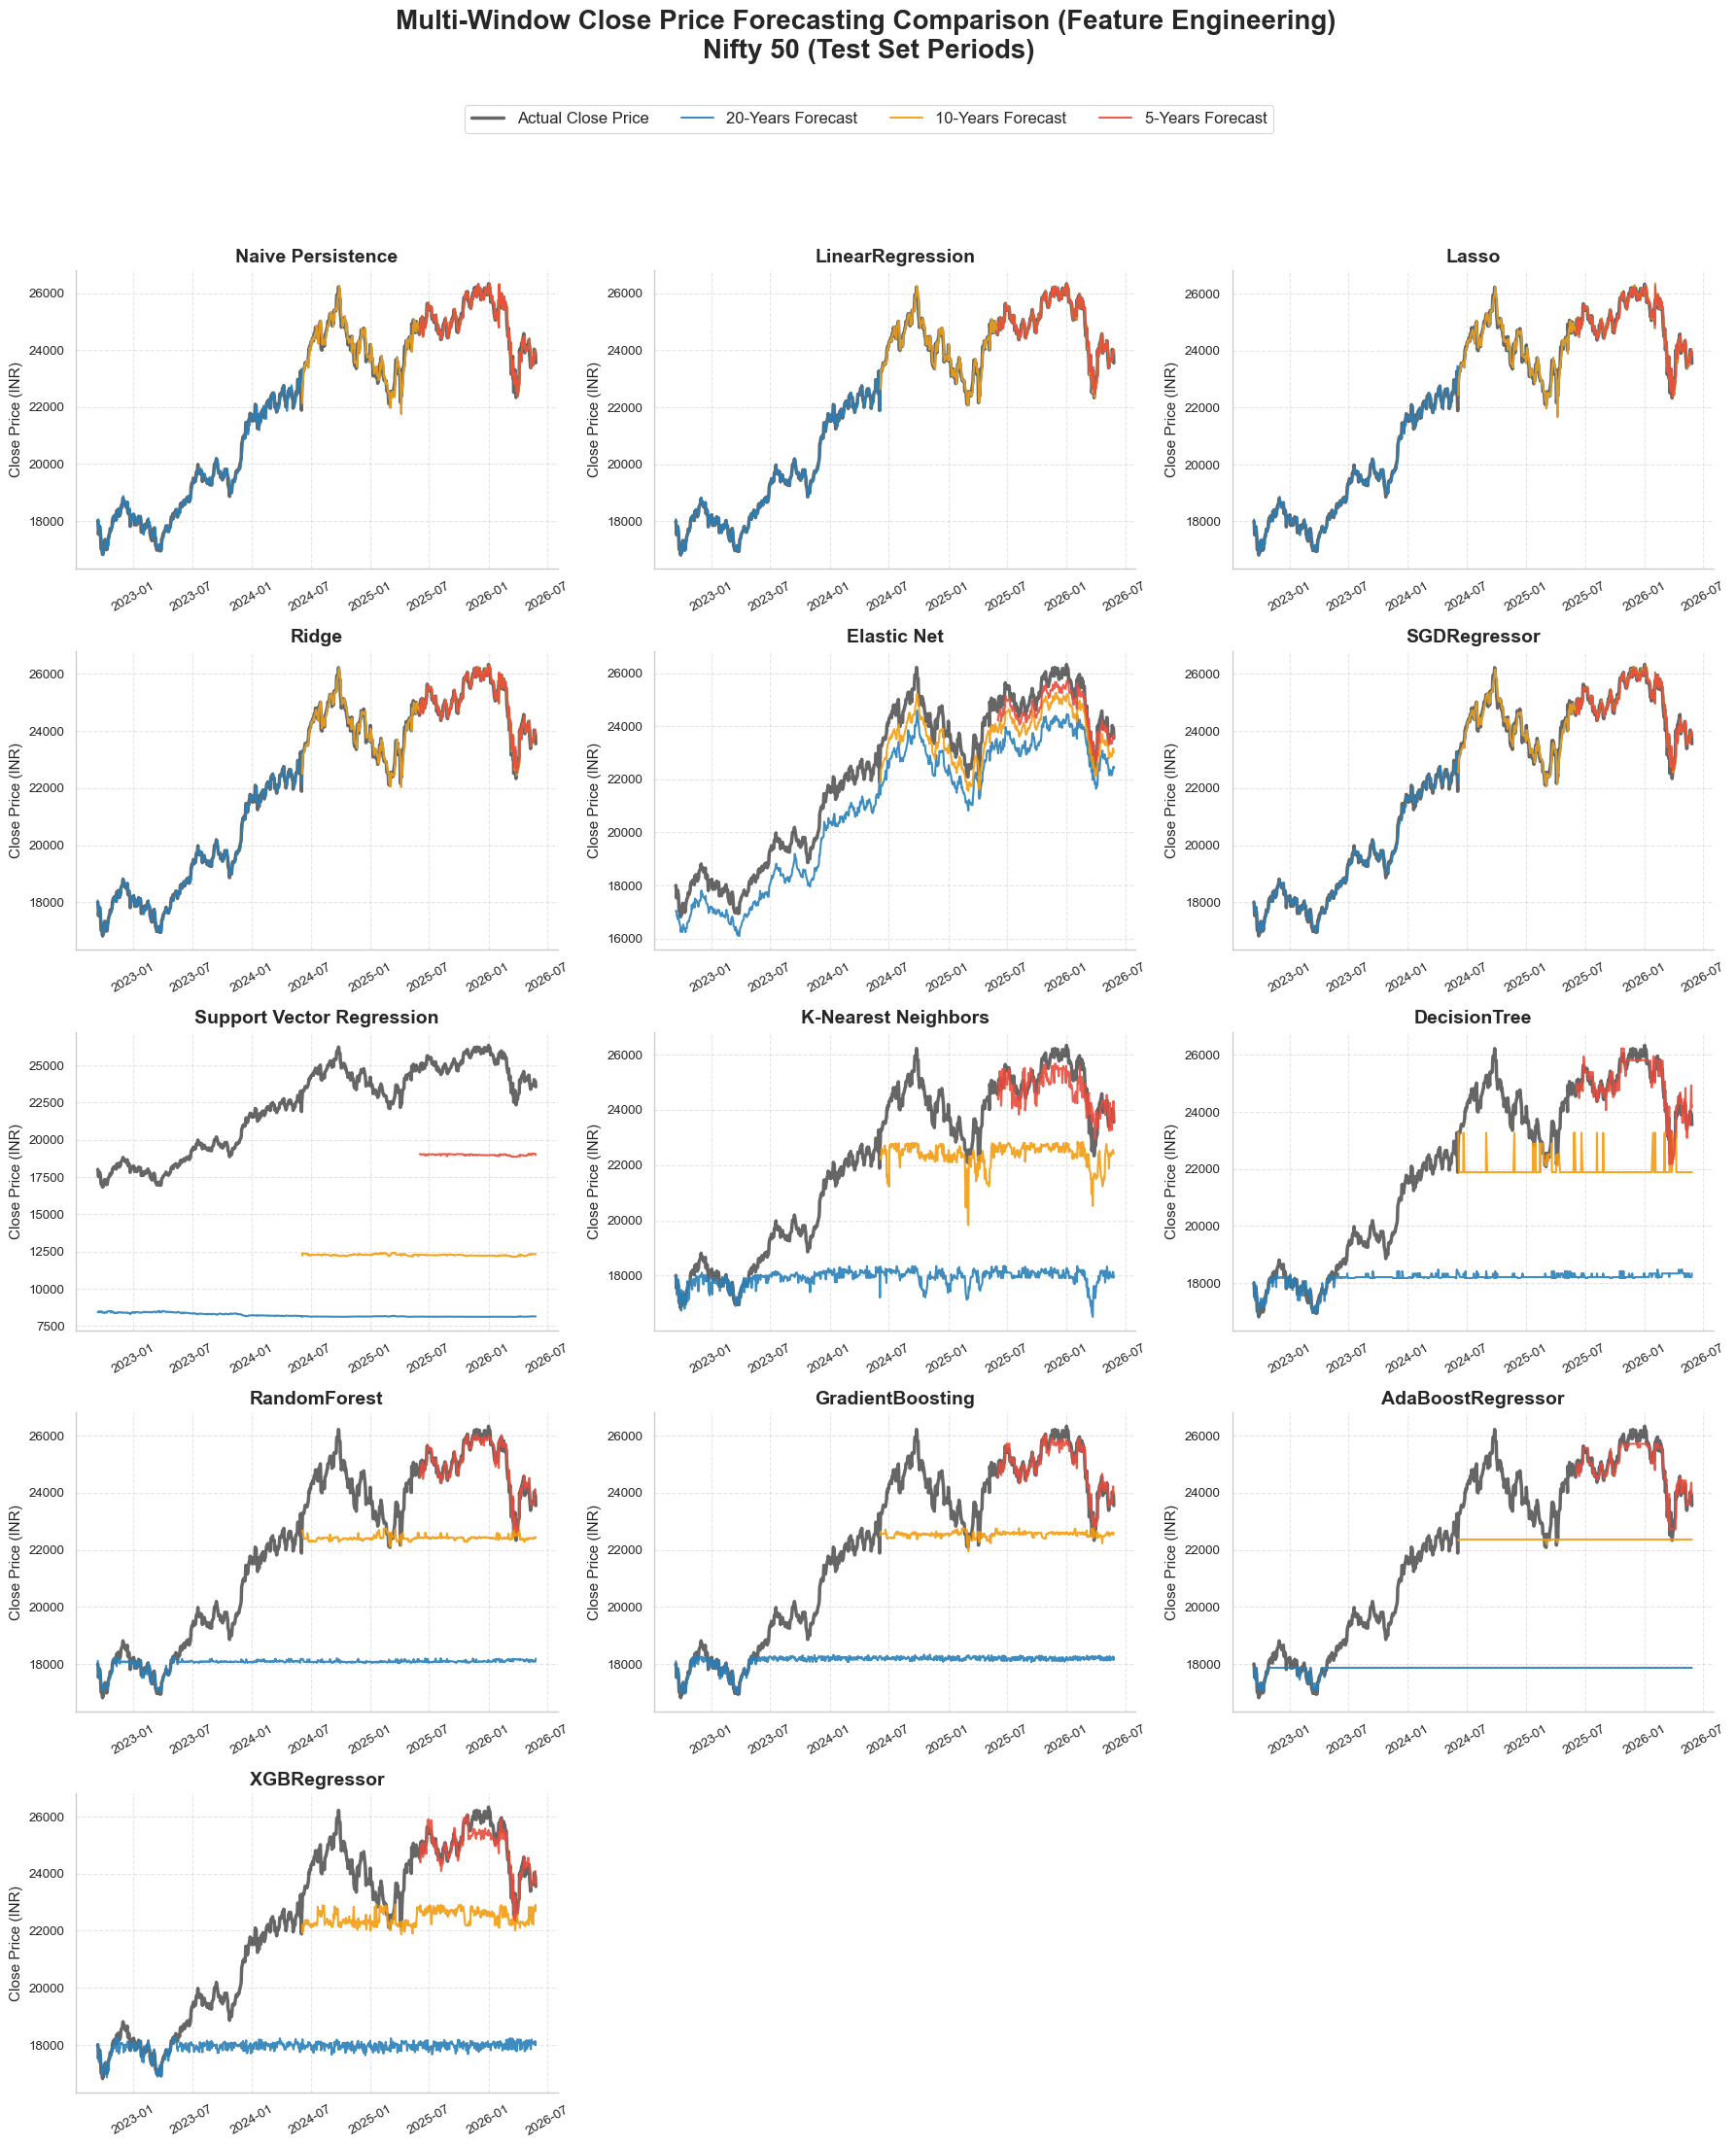

In [6]:
def plot_consolidated_predictions(company_name):
    """
    Plots Actual vs 5-Year, 10-Year, and 20-Year predictions 
    on a single graph for each model.
    """
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.1)
    
    n_models = len(models)
    n_cols = 3 
    n_rows = math.ceil(n_models / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows), sharex=False)
    axes = axes.flatten()
    
    fig.suptitle(f"Multi-Window Close Price Forecasting Comparison (Feature Engineering) \n{company_name} (Test Set Periods)", 
                 fontsize=20, fontweight='bold', y=0.98)
    
    colors = {
        "5_Years": "#e74c3c",   
        "10_Years": "#f39c12",  
        "20_Years": "#2980b9"   
    }
    
    # Define the order (plot longest to shortest so shorter lines render on top)
    horizon_order = ["20_Years", "10_Years", "5_Years"]
    
    for i, model_name in enumerate(models.keys()):
        ax = axes[i]
        
        # 1. Plot the Actual Prices (Using the longest 20-year test set as the baseline)
        key_20 = (company_name, "20_Years")
        if key_20 in plot_data_store:
            y_actual_20 = plot_data_store[key_20]['y_test']
            ax.plot(y_actual_20.index, y_actual_20.values, color="black", 
                    linewidth=2.5, label="Actual Close Price", alpha=0.6)
            
        # 2. Loop through horizons and plot the predictions
        for horizon_name in horizon_order:
            key = (company_name, horizon_name)
            if key not in plot_data_store: 
                continue
                
            y_test = plot_data_store[key]['y_test']
            y_pred = plot_data_store[key]['predictions'][model_name]
            
            # Create a pandas Series to align the predictions with the real dates
            pred_series = pd.Series(y_pred, index=y_test.index)
            
            label_name = horizon_name.replace("_", "-") + " Forecast"
            ax.plot(pred_series.index, pred_series.values, color=colors[horizon_name], 
                    linewidth=1.5, label=label_name, alpha=0.9)
            
        # Formatting the subplot
        ax.set_title(f"{model_name}", fontsize=14, fontweight='bold')
        ax.set_ylabel("Close Price (INR)", fontsize=11)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        # Make the x-axis dates readable
        ax.tick_params(axis='x', rotation=30)
        sns.despine(ax=ax)
        
    # Remove any empty subplots if the grid isn't perfectly filled
    for j in range(n_models, len(axes)): 
        fig.delaxes(axes[j])
        
    # Extract handles for a single master legend at the top
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", bbox_to_anchor=(0.5, 0.94), 
               ncol=4, frameon=True, fontsize=12)
    
    # Adjust layout to make room for the master title and legend
    plt.tight_layout(rect=[0, 0, 1, 0.91])
    
    # Save the figure in high-res for your paper before showing it
    plt.savefig(f"{company_name}_close_baseline_engineered_performance_forecast.png", dpi=300, bbox_inches='tight')
    plt.show()

# Execute the visualization
plot_consolidated_predictions("Nifty 50")